In [ ]:
# HyperOpt 를 찾기 위한 기본 루틴 정리본 ,
# 본 파일을 save_as 이니셜_1.모델축약어_FindHO.ipynb 로 저장하세요~ ex) lkj_1.XGB_FindHO.ipynb

In [1]:
import sys
import os

project_root = 'c:/big20/git/big20-ML-project2-team3/CreditCardFraud'

# sys.path에 추가 (모듈 import용)
if project_root not in sys.path:
    sys.path.insert(0, project_root)

In [2]:
import pandas as pd
import numpy  as np
from scipy.special import logit
import time
import warnings
warnings.filterwarnings("ignore")
from pathlib import Path
import math

from xgboost import XGBClassifier, plot_importance
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier
from sklearn.ensemble import RandomForestClassifier, StackingClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.model_selection import train_test_split, KFold, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression, LinearRegression
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, roc_curve, classification_report, confusion_matrix, recall_score, precision_score
from sklearn.datasets import make_classification
from hyperopt import fmin, tpe, hp, STATUS_OK, Trials

import matplotlib
import matplotlib.pyplot as plt
plt.rcParams['font.family'] ='Malgun Gothic'
matplotlib.rcParams['axes.unicode_minus'] = False
import seaborn as sns

import importlib
from utils import preprocessing
importlib.reload(preprocessing) # 모듈 reload
# importlib.reload(user_utils)

import utils.preprocessing as pp
import utils.user_utils    as uu
import utils.model_utils   as mu
import utils.evaluation    as ev
import utils.modeling      as mo
import utils.data_sampling as ds

# train = pd.read_csv("../data/train.csv")
# test  = pd.read_csv("../data/test.csv")

In [3]:
# 결과받을 딕셔너리
results = {}
team_rs = 23 # 우리팀 random_state

In [4]:
#1. 데이터 로딩
raw_df = pp.ccf_load_data()

데이터 로드 성공: (284807, 31)


In [5]:
# 2. Time 컬럼 삭제 , 데이터,타겟 분리
X_features, y_target = pp.split_features_target(raw_df, cols= 'Time')

In [6]:
# 3. 이상치를 경계값으로 치환
cap_X_feature = pp.cap_outliers(X_features)

In [7]:
# 4.1 학습/테스트 데이터 분리
X_train, X_test, y_train, y_test = pp.data_split(cap_X_feature, y_target)

In [8]:
# 5.1 학습/검증 데이터 분리
X_tr, X_val, y_tr, y_val = pp.data_split(X_train, y_train, size=0.4)

In [9]:
# 4.2 Over Sampling 하는 경우
X_over, y_over = ds.oversampling_smote(X_train, y_train)

✅ SMOTE 오버샘플링 완료
   원본 샘플 수: 227845 (Class 0: 227451, Class 1: 394)
   샘플링 후: 454902 (Class 0: 227451, Class 1: 227451)


In [10]:
# 5.2 Over Sampling한 경우 학습/검증 데이터 분리
X_tr_over, X_val_over, y_tr_over, y_val_over = pp.data_split(X_over, y_over, size=0.4)

In [11]:
# 5-1. train/test 전체에 대해 스케일러 학습 & 변환
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# 5-2. HyperOpt용 train/val 분리 (스케일된 데이터 기준)
#     - y_tr, y_val도 다시 분리
X_tr_scaled, X_val_scaled, y_tr_scaled, y_val_scaled = pp.data_split(
    X_train_scaled, y_train, size=0.4
)

# 6. HyperOpt 튜너 설정 (AUC 기준으로 최적화)
tuner = uu.HyperOptTuner(
    max_evals=100,
    metric="roc_auc",   # 이진 분류에서 제일 무난
    random_state=team_rs
)

In [ ]:
#6 하이퍼파라미터
tuner = uu.HyperOptTuner(max_evals=100, random_state=23)

# 모델별 스페이스 생성 : 예시는 catboost
logreg_search_space = {
    "C": hp.loguniform("C", np.log(1e-3), np.log(1e2)),  # 0.001 ~ 100
    "max_iter": hp.quniform("max_iter", 200, 800, 50),
    # class_weight는 balanced vs None 비교
    "class_weight": hp.choice("class_weight", [None, "balanced"]),
    # solver와 penalty는 안전하게 고정
    "solver": hp.choice("solver", ["lbfgs"]),
    "penalty": hp.choice("penalty", ["l2"]),
}

# 8. HyperOpt 실행 (원 데이터에 oversampling 안 한 버전)
logreg_model = LogisticRegression()

best_log_params, best_log_model, log_trials, log_time = tuner.tune(
    model=logreg_model,
    X_train=X_tr_scaled,
    y_train=y_tr_scaled,
    X_val=X_val_scaled,
    y_val=y_val_scaled,
    search_space=logreg_search_space,
)

print("\n[LogisticRegression] Best Params:", best_log_params)
print(f"[LogisticRegression] HyperOpt time: {log_time:.2f}초")


LogisticRegression 튜닝 시작
100%|██████████| 100/100 [02:29<00:00,  1.49s/trial, best loss: -0.9820394522652078]

튜닝 시간: 149.38초
최적 roc_auc: 0.9820

최적 모델의 전체 평가 점수:
- roc_auc: 0.9820
- f1: 0.0955
- precision: 0.0503
- recall: 0.9304
- accuracy: 0.9694

[LogisticRegression] Best Params: {'C': 48.99128351532987, 'class_weight': 'balanced', 'max_iter': 250, 'penalty': 'l2', 'solver': 'lbfgs', 'random_state': 23, 'n_jobs': -1}
[LogisticRegression] HyperOpt time: 149.38초


In [16]:
# 9. 최적 파라미터로 train 전체 재학습 후, test 평가 + 저장
#    - X_train_scaled, X_test_scaled 사용
best_logreg = LogisticRegression(**best_log_params)

log_model_name = "LoR_ho_best"

results[log_model_name] = uu.get_model_train_eval(
    best_logreg,
    log_model_name,
    X_train_scaled,
    X_test_scaled,
    y_train,
    y_test,
    hyperopt_params=best_log_params
)

print("\n[LogisticRegression] 최종 결과:")
print(results[log_model_name])

✓ 모델 저장 완료: ../models\LoR_ho_best.pkl
  파일 크기: 0.00 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9657, '정확도': 0.9710, '정밀도': 0.0504, '재현율': 0.8878, 'F1': 0.0954 }
{'오차행렬':
[[55225  1639]
 [   11    87]] }
실행 시간: 3.532196044921875
하이퍼파라미터: {'C': 48.99128351532987, 'class_weight': 'balanced', 'max_iter': 250, 'penalty': 'l2', 'solver': 'lbfgs', 'random_state': 23, 'n_jobs': -1}

[LogisticRegression] 최종 결과:
{'AUC': 0.9657, '정밀도': 0.0504, '재현율': 0.8878, 'F1': 0.0954}


In [17]:
# =========================
# 8. LogisticRegression HyperOpt (SMOTE 오버샘플링 버전)
# =========================

# 8-1. 오버샘플링된 데이터에 대해 별도 스케일러 적용
scaler_over = StandardScaler()
X_over_scaled = scaler_over.fit_transform(X_over)
X_test_scaled_over = scaler_over.transform(X_test)

# 8-2. HyperOpt용 train/val 분리 (오버샘플링 + 스케일된 데이터 기준)
X_tr_over_scaled, X_val_over_scaled, y_tr_over_scaled, y_val_over_scaled = pp.data_split(
    X_over_scaled, y_over, size=0.4
)

# 8-3. 같은 search space / tuner로 HyperOpt 수행
best_log_over_params, best_log_over_model, log_over_trials, log_over_time = tuner.tune(
    model=logreg_model,
    X_train=X_tr_over_scaled,
    y_train=y_tr_over_scaled,
    X_val=X_val_over_scaled,
    y_val=y_val_over_scaled,
    search_space=logreg_search_space,
)

print("\n[LogisticRegression - SMOTE] Best Params:", best_log_over_params)
print(f"[LogisticRegression - SMOTE] HyperOpt time: {log_over_time:.2f}초")



LogisticRegression 튜닝 시작
100%|██████████| 100/100 [03:03<00:00,  1.83s/trial, best loss: -0.993700774476793]

튜닝 시간: 183.26초
최적 roc_auc: 0.9937

최적 모델의 전체 평가 점수:
- roc_auc: 0.9937
- f1: 0.9595
- precision: 0.9726
- recall: 0.9467
- accuracy: 0.9600

[LogisticRegression - SMOTE] Best Params: {'C': 99.78576192595759, 'class_weight': 'balanced', 'max_iter': 550, 'penalty': 'l2', 'solver': 'lbfgs', 'random_state': 23, 'n_jobs': -1}
[LogisticRegression - SMOTE] HyperOpt time: 183.26초


In [18]:
# 8-4. 최적 파라미터로 오버샘플링 train 전체 재학습 후, 원래 test 평가
best_logreg_over = LogisticRegression(**best_log_over_params)
log_over_model_name = "LoR_over_ho_best"

results[log_over_model_name] = uu.get_model_train_eval(
    best_logreg_over,
    log_over_model_name,
    X_over_scaled,        # 학습: SMOTE로 늘린 train 전체
    X_test_scaled_over,   # 평가: 원본 test를 같은 scaler_over로 스케일링
    y_over,
    y_test,
    hyperopt_params=best_log_over_params
)

print("\n[LogisticRegression - SMOTE] 최종 결과:")
print(results[log_over_model_name])

✓ 모델 저장 완료: ../models\LoR_over_ho_best.pkl
  파일 크기: 0.00 MB
folder = c:\big20\git\big20-ML-project2-team3\CreditCardFraud\results
{'AUC': 0.9642, '정확도': 0.9733, '정밀도': 0.0544, '재현율': 0.8878, 'F1': 0.1025 }
{'오차행렬':
[[55352  1512]
 [   11    87]] }
실행 시간: 2.011962652206421
하이퍼파라미터: {'C': 99.78576192595759, 'class_weight': 'balanced', 'max_iter': 550, 'penalty': 'l2', 'solver': 'lbfgs', 'random_state': 23, 'n_jobs': -1}

[LogisticRegression - SMOTE] 최종 결과:
{'AUC': 0.9642, '정밀도': 0.0544, '재현율': 0.8878, 'F1': 0.1025}


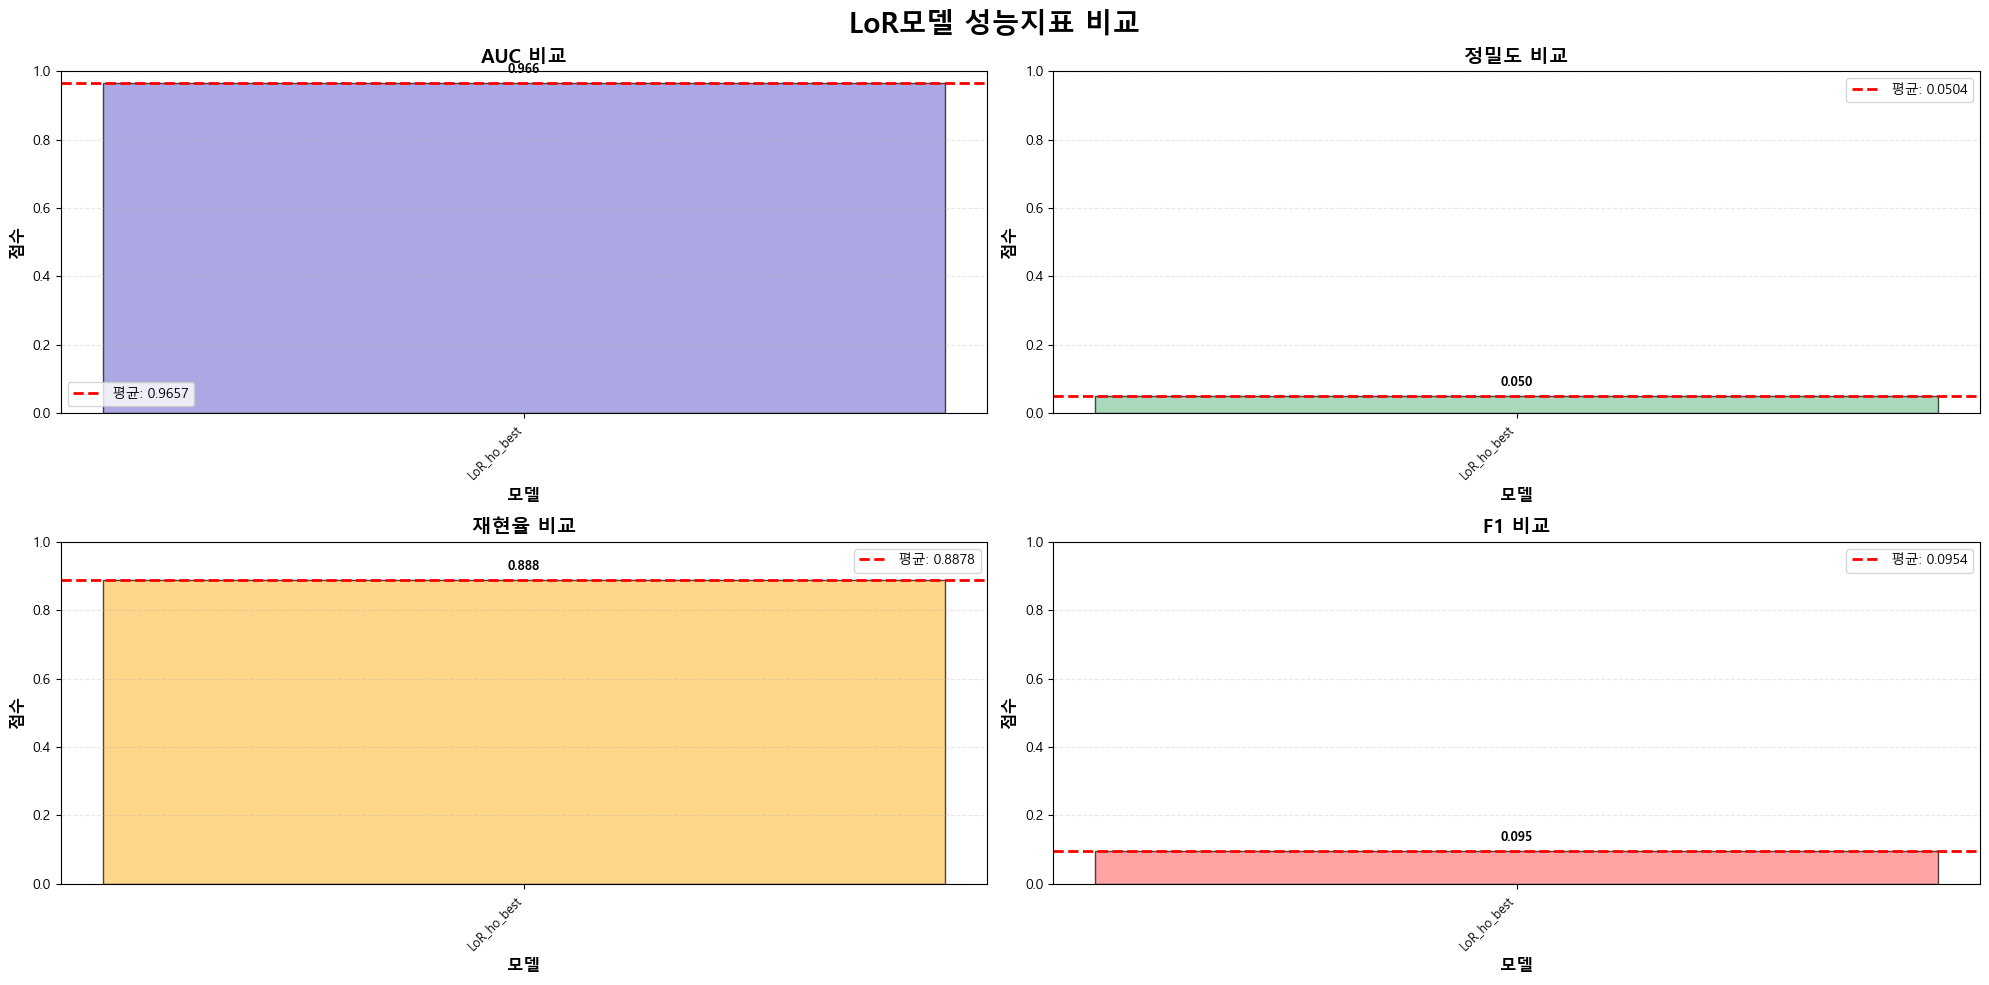


=== 지표별 통계 요약 ===

[AUC]
  최고: 0.9657 (LoR_ho_best)
  최저: 0.9657 (LoR_ho_best)
  평균: 0.9657
  표준편차: nan

[정밀도]
  최고: 0.0504 (LoR_ho_best)
  최저: 0.0504 (LoR_ho_best)
  평균: 0.0504
  표준편차: nan

[재현율]
  최고: 0.8878 (LoR_ho_best)
  최저: 0.8878 (LoR_ho_best)
  평균: 0.8878
  표준편차: nan

[F1]
  최고: 0.0954 (LoR_ho_best)
  최저: 0.0954 (LoR_ho_best)
  평균: 0.0954
  표준편차: nan


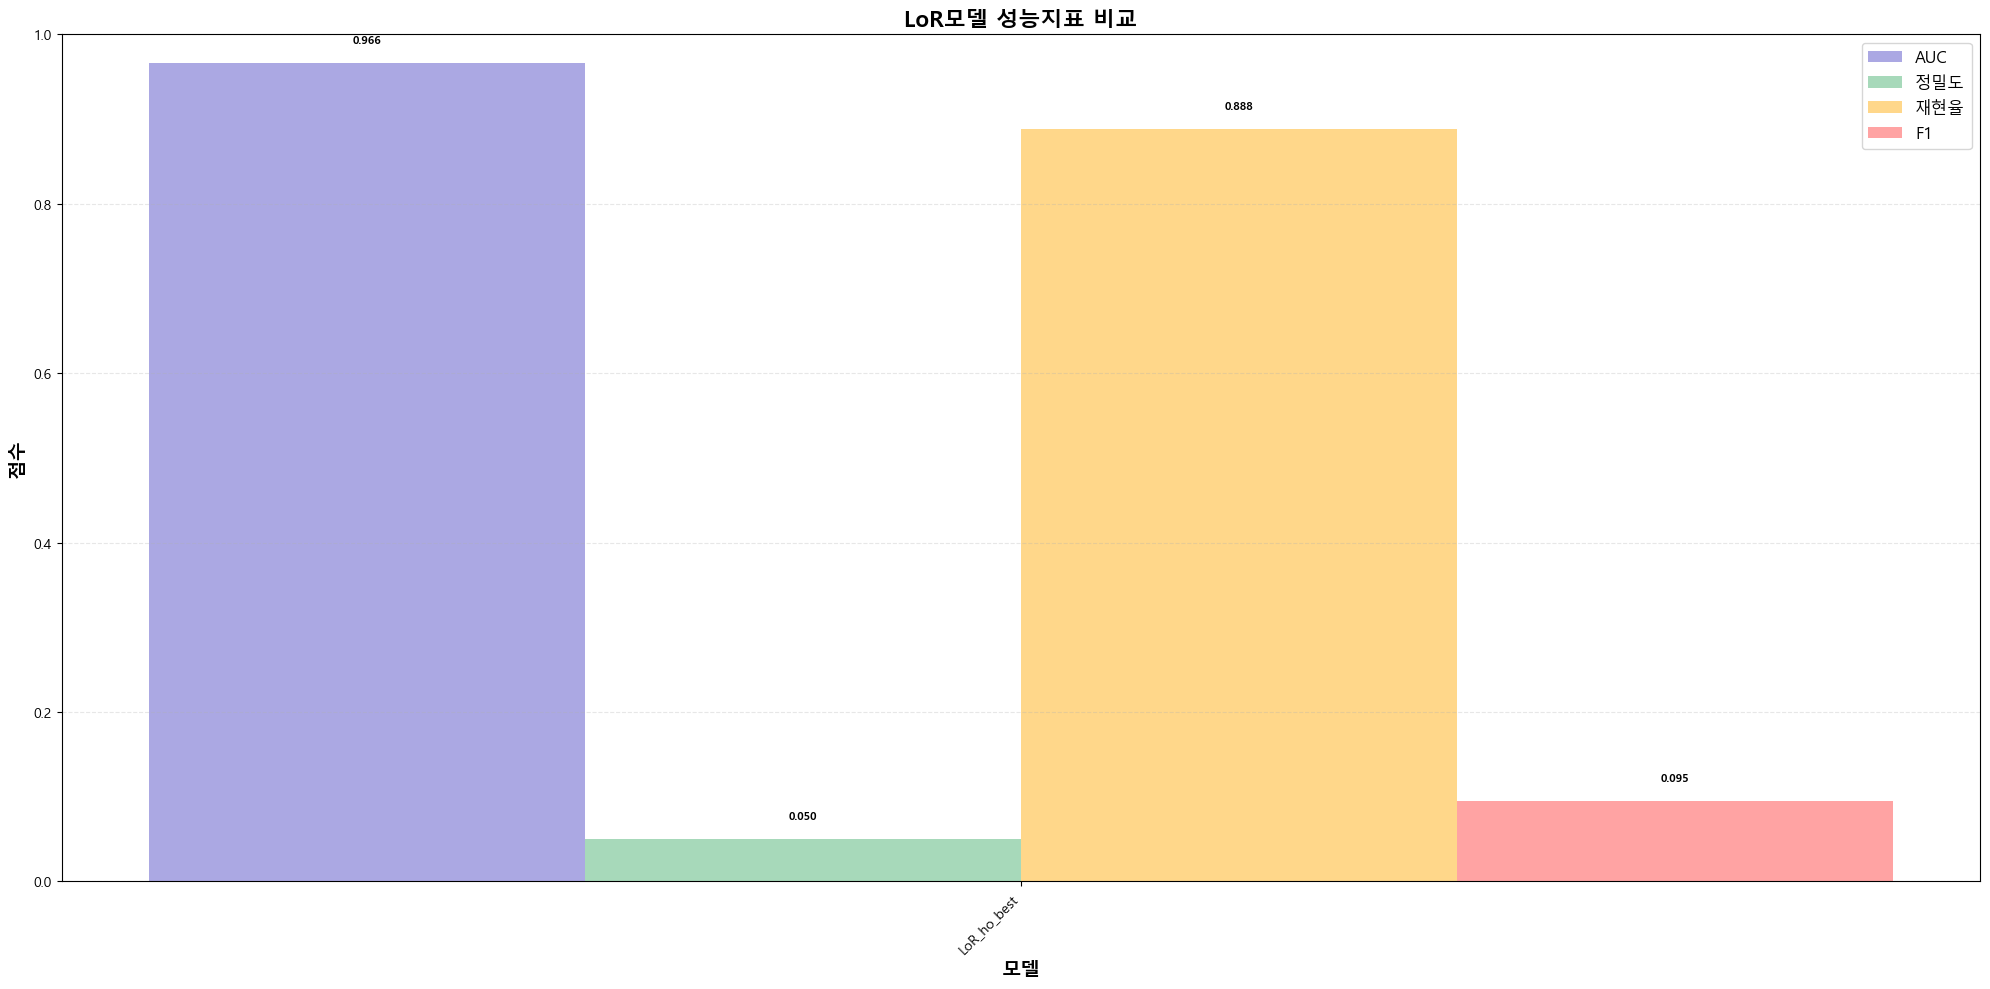


=== F1 Score 기준 상위 5개 모델 ===
                AUC     정밀도     재현율      F1
LoR_ho_best  0.9657  0.0504  0.8878  0.0954

=== AUC 기준 상위 5개 모델 ===
                AUC     정밀도     재현율      F1
LoR_ho_best  0.9657  0.0504  0.8878  0.0954

그래프가 저장되었습니다: ../images/LoR모델_성능지표_비교_2025_1130.png


In [14]:
# 7 시각화
mo.model_metrics_graph(results, 'LoR모델 성능지표 비교')

In [20]:
# ============================================
# thresholds별 튜닝 접근 (LogisticRegression용)
# ============================================

from sklearn.metrics import precision_recall_curve  # 위에서 안 했으면 한 번만 추가

def threshold_tuning_logreg(model, X_test, y_test, model_name="LogReg"):
    """
    - model: 학습 완료된 LogisticRegression (predict_proba 사용 가능)
    - X_test, y_test: 평가용 데이터
    - model_name: 표/그래프 제목용 라벨
    """
    # 1) 예측 확률
    y_pred_proba = model.predict_proba(X_test)[:, 1]

    # 2) threshold 그리드 정의 (0.1 ~ 0.9)
    thresholds = np.arange(0.1, 0.91, 0.1)
    results_threshold = []

    for thr in thresholds:
        y_pred_thr = (y_pred_proba >= thr).astype(int)

        precision = precision_score(y_test, y_pred_thr, zero_division=0)
        recall    = recall_score(y_test, y_pred_thr, zero_division=0)
        f1        = f1_score(y_test, y_pred_thr, zero_division=0)
        # AUC는 threshold와 무관하니 한 번만 계산해도 되지만,
        # yjh 코드 스타일 맞춰서 그대로 넣어준다.
        auc       = roc_auc_score(y_test, y_pred_proba)

        results_threshold.append({
            "threshold": thr,
            "precision": precision,
            "recall":    recall,
            "f1":        f1,
            "auc":       auc
        })

    # 3) DataFrame으로 정리
    df_thr = pd.DataFrame(results_threshold)
    print(f"\n==== {model_name} threshold별 성능 ====")
    print(df_thr)

    # 4) Precision-Recall 곡선 시각화
    precisions, recalls, thr_pr = precision_recall_curve(y_test, y_pred_proba)

    plt.figure(figsize=(8, 5))
    plt.plot(thr_pr, precisions[:-1], "b--", label="Precision")
    plt.plot(thr_pr, recalls[:-1],    "g-",  label="Recall")
    plt.title(f"{model_name} - Threshold vs Precision/Recall")
    plt.xlabel("Threshold")
    plt.ylabel("Score")
    plt.legend()
    plt.grid(True, linestyle="--", alpha=0.5)
    plt.show()

    return df_thr


==== LoR_ho_best threshold별 성능 ====
   threshold  precision    recall        f1       auc
0        0.1   0.009458  0.938776  0.018728  0.965712
1        0.2   0.016627  0.918367  0.032662  0.965712
2        0.3   0.025552  0.897959  0.049689  0.965712
3        0.4   0.036409  0.897959  0.069980  0.965712
4        0.5   0.050406  0.887755  0.095395  0.965712
5        0.6   0.069157  0.887755  0.128319  0.965712
6        0.7   0.094549  0.867347  0.170512  0.965712
7        0.8   0.135703  0.857143  0.234310  0.965712
8        0.9   0.244838  0.846939  0.379863  0.965712


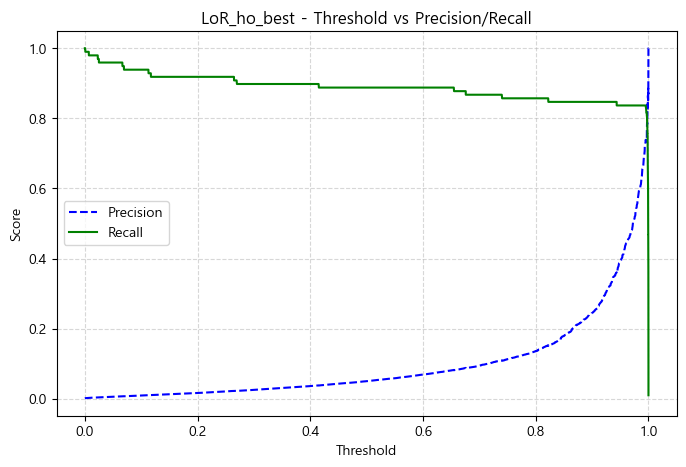

In [21]:
# 기본 LogisticRegression (LoR_ho_best)에 대해 threshold 튜닝
df_thr_log_base = threshold_tuning_logreg(
    model=best_logreg,          # 이미 HyperOpt로 튜닝된 LR
    X_test=X_test_scaled,       # StandardScaler 적용된 원본 test
    y_test=y_test,
    model_name="LoR_ho_best"
)


==== LoR_over_ho_best threshold별 성능 ====
   threshold  precision    recall        f1      auc
0        0.1   0.011313  0.928571  0.022353  0.96424
1        0.2   0.020357  0.918367  0.039832  0.96424
2        0.3   0.029600  0.897959  0.057310  0.96424
3        0.4   0.040807  0.887755  0.078027  0.96424
4        0.5   0.054409  0.887755  0.102534  0.96424
5        0.6   0.071547  0.877551  0.132308  0.96424
6        0.7   0.096552  0.857143  0.173554  0.96424
7        0.8   0.138796  0.846939  0.238506  0.96424
8        0.9   0.224932  0.846939  0.355460  0.96424


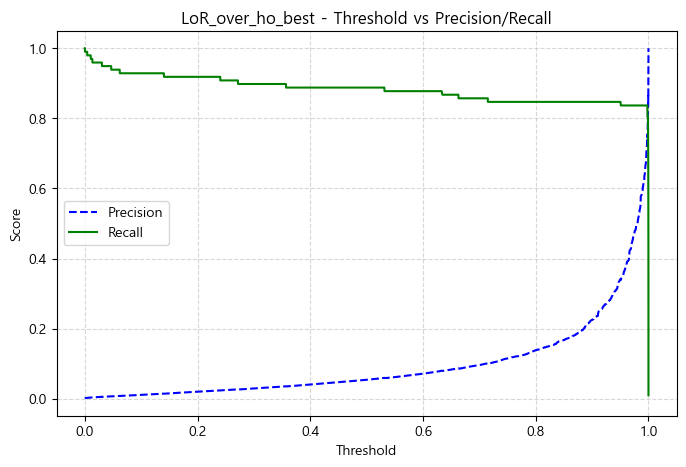

In [22]:
# SMOTE LogisticRegression (LoR_over_ho_best)에 대해 threshold 튜닝
df_thr_log_over = threshold_tuning_logreg(
    model=best_logreg_over,     # SMOTE + HyperOpt 버전 LR
    X_test=X_test_scaled_over,  # SMOTE용 scaler로 변환된 test
    y_test=y_test,
    model_name="LoR_over_ho_best"
)

In [ ]:
# BestOpt 찾고 나서 스케일적용 버전 만들어서 모델링하기
# X_train_scaled, X_test_scaled, scaler = pp.scale_data(X_train, X_test)